# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [12]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [13]:
# Inspect the shapes of the datasets
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Convert labels to one-hot encoding
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


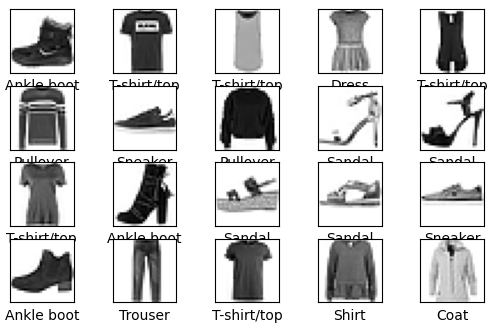

In [14]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
for i in range(20):
    plt.subplot(5,5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i].argmax()])
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Answer:** The dataset seems as expected, however, many images are blurred. Some images appear similar at a first glance, for example : the dress and long top on the top right, that might cause confusion during classification.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(10, activation='softmax'))

# Compile the model using `model.compile()`
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics = ['accuracy'])
# Train the model with `model.fit()`
history = model.fit(X_train, y_train, epochs=10, validation_split=0.25)
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7162 - loss: 0.8378 - val_accuracy: 0.8245 - val_loss: 0.5143
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8356 - loss: 0.4870 - val_accuracy: 0.8277 - val_loss: 0.4878
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8427 - loss: 0.4580 - val_accuracy: 0.8423 - val_loss: 0.4516
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8541 - loss: 0.4305 - val_accuracy: 0.8446 - val_loss: 0.4418
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8534 - loss: 0.4246 - val_accuracy: 0.8455 - val_loss: 0.4433
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8573 - loss: 0.4118 - val_accuracy: 0.8499 - val_loss: 0.4311
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8604 - loss: 0.4028 - val_accuracy: 0.8557 - val_loss: 0.4189
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8614 - loss: 0.3980 - 

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Answer:** The accuracy of 84.6 is good to start. However since the model uses a flattened version of the dataset, the relationships between pixels is lost. Therefore the relatively high accuracy of the linear model still does not completely hold for the original image dataset.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [17]:
from keras.layers import Conv2D, MaxPooling2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28, 1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=10, validation_split=0.25)
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)

/Users/divitanarang/miniconda/envs/zoomcamp/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7848 - loss: 0.6309 - val_accuracy: 0.8731 - val_loss: 0.3601
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.8848 - loss: 0.3277 - val_accuracy: 0.8801 - val_loss: 0.3354
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.8975 - loss: 0.2883 - val_accuracy: 0.8966 - val_loss: 0.2910
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9084 - loss: 0.2619 - val_accuracy: 0.9022 - val_loss: 0.2832
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.9149 - loss: 0.2447 - val_accuracy: 0.8989 - val_loss: 0.2843
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9192 - loss: 0.2276 - val_accuracy: 0.9037 - val_loss: 0.2726
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9246 - loss: 0.2152 - val_accuracy: 0.9031 - val_loss: 0.2728
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9299 -

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Answer:** Using the CNN model, the accuarcy went up to 89.9%. The different layers also keep the spatial relationships in place, so the accuracy metric can be considered reliable.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [22]:
# A. Test Hyperparameters
import pandas as pd
number_filters_choice = [32,64,128]
results_with_hyperparameters = []

for number_filters in number_filters_choice:
    model_with_hyperparameters = Sequential()
    model_with_hyperparameters.add(Conv2D(number_filters, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
    model_with_hyperparameters.add(MaxPooling2D(pool_size=(2,2)))
    model_with_hyperparameters.add(Flatten())
    model_with_hyperparameters.add(Dense(10, activation='softmax'))

    model_with_hyperparameters.compile(optimizer='adam',
                                       loss = 'categorical_crossentropy',
                                       metrics=['accuracy'])
    history_with_hyperparameters=model_with_hyperparameters.fit(X_train, y_train, epochs=5, validation_split=0.25)

    loss, accuracy = model_with_hyperparameters.evaluate(X_test, y_test)
    results_with_hyperparameters.append({
        'experiment' : 'hyperparameters',
        'hyperparameter' : number_filters,
        'value' : number_filters,
        'accuracy' : accuracy,
        'loss' : loss
    })

results = pd.DataFrame(results_with_hyperparameters)
results
   

/Users/divitanarang/miniconda/envs/zoomcamp/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.7812 - loss: 0.6410 - val_accuracy: 0.8727 - val_loss: 0.3559
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.8829 - loss: 0.3306 - val_accuracy: 0.8885 - val_loss: 0.3131
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.8986 - loss: 0.2852 - val_accuracy: 0.8951 - val_loss: 0.2945
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.9085 - loss: 0.2576 - val_accuracy: 0.8895 - val_loss: 0.3065
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.9150 - loss: 0.2393 - val_accuracy: 0.9031 - val_loss: 0.2737
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9011 - loss: 0.2863
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.7877 - loss: 0.6069 - val_accuracy: 0.8735 - val_loss: 0.3582
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.8893 - loss: 0.3205 - val_accuracy: 0.8939 - val_loss: 0.3031
Epoch 3/

,experiment,hyperparameter,value,accuracy,loss
0,hyperparameters,32,32,0.8974,0.285580
1,hyperparameters,64,64,0.8932,0.296091
2,hyperparameters,128,128,0.8990,0.280223


In [21]:
# B. Test presence or absence of regularization
from keras.layers import Dropout
dropout_options = [False, True]
results_with_regularisation = []

fixed_filters = 64

for dropout in dropout_options:
    model_regularisation = Sequential()
    model_regularisation.add(Conv2D(fixed_filters, kernel_size=(3,3),activation='relu', input_shape=(28,28,1)))
    model_regularisation.add(MaxPooling2D(pool_size=(2,2)))
    model_regularisation.add(Flatten())

    if dropout:
        model_regularisation.add(Dropout(0.5))
    model_regularisation.add(Dense(10, activation='softmax'))

    model_regularisation.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    history_regularisation = model_regularisation.fit(X_train, y_train, epochs=5, validation_split=0.25)

    loss, accuracy = model_regularisation.evaluate(X_test, y_test)
    results_with_regularisation.append({
        'experiment' : 'regularisation',
        'hyperparameter' : 'dropout',
        'value' : dropout,
        'accuracy' : accuracy,
        'loss' : loss
    })

results = pd.DataFrame(results_with_regularisation)
results

/Users/divitanarang/miniconda/envs/zoomcamp/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.7906 - loss: 0.6048 - val_accuracy: 0.8766 - val_loss: 0.3462
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8894 - loss: 0.3167 - val_accuracy: 0.8967 - val_loss: 0.2959
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9018 - loss: 0.2750 - val_accuracy: 0.8957 - val_loss: 0.2952
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.9136 - loss: 0.2472 - val_accuracy: 0.9033 - val_loss: 0.2708
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9224 - loss: 0.2207 - val_accuracy: 0.8981 - val_loss: 0.2810
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9004 - loss: 0.2881
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 36ms/step - accuracy: 0.7788 - loss: 0.6319 - val_accuracy: 0.8751 - val_loss: 0.3529
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.8750 - loss: 0.3507 - val_accuracy: 0.8848 - val_loss: 0.3248
Epoch 3/

,experiment,hyperparameter,value,accuracy,loss
0,regularisation,dropout,False,0.8962,0.290482
1,regularisation,dropout,True,0.8920,0.297143


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Answer:** Both Hyperparameter tuning and Regularisation improved the model's accuracy scores.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [23]:
# A. Test Hyperparameters
import pandas as pd
number_filters = 64

final_model = Sequential()
final_model.add(Conv2D(number_filters, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
final_model.add(MaxPooling2D(pool_size=(2,2)))
final_model.add(Flatten())
final_model.add(Dense(10, activation='softmax'))

final_model.compile(optimizer='adam',loss = 'categorical_crossentropy',metrics=['accuracy'])
history_model=final_model.fit(X_train, y_train, epochs=5, validation_split=0.25)

loss, accuracy = final_model.evaluate(X_test, y_test)
print('Final model metrics : {accuracy} {loss}')


/Users/divitanarang/miniconda/envs/zoomcamp/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.7934 - loss: 0.5904 - val_accuracy: 0.8833 - val_loss: 0.3323
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.8905 - loss: 0.3088 - val_accuracy: 0.8935 - val_loss: 0.2977
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.9033 - loss: 0.2700 - val_accuracy: 0.8997 - val_loss: 0.2863
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.9123 - loss: 0.2456 - val_accuracy: 0.9009 - val_loss: 0.2797
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.9216 - loss: 0.2226 - val_accuracy: 0.8982 - val_loss: 0.2863
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8928 - loss: 0.3083
Final model metrics : {accuracy} {loss}


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Answer** : The model accuracy improved significantly over the base model by hyperparameter tuning in the previous steps and using 64 filters as that produced the best results.
With more time available, Grid Search can also be used for hyperparameter tuning and evaluation further results.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.